### Web scraping para obtener los datos del valor de la tasa de cambio de eltoque.com durante los ultimos 2 años.



In [1]:
import pandas as pd
import numpy as np
import requests
import json

In [2]:


urls = [
    'https://api.cubanomic.com/api/v1/x-rates-by-date-range-history?trmi=true&cur=USD&token=CUBANOMIC_TOKEN_REDACTED&period=730D',
    'https://api.cubanomic.com/api/v1/x-rates-by-date-range-history?trmi=true&cur=ECU&token=CUBANOMIC_TOKEN_REDACTED&period=730D',
]

# Obtener todos los datos
all_data = []
for url in urls:
    response = requests.get(url)
    data = response.json()
    all_data.append(data)
    print(f"Datos de {url.split('cur=')[1].split('&')[0]}: {len(data)} registros")

# Guardar en archivo
with open('./data/tasas_de_cambio.json', 'w', encoding='utf-8') as f:
    json.dump(all_data, f, ensure_ascii=False, indent=2)

print("Datos guardados en 'tasas_de_cambio.json'")

Datos de USD: 722 registros
Datos de ECU: 726 registros
Datos guardados en 'tasas_de_cambio.json'


In [3]:
# Cargar datos
with open('data/tasas_de_cambio.json', 'r') as f:
    data_with_list = json.load(f)

print(data_with_list)

[[{'_id': '2024-01-18', 'avg': 275.12, 'count_values': 585, 'cur': 'USD', 'first': {'date': '2024-01-17 07:01:16', 'value': 278.0}, 'last': {'date': '2024-01-18 06:59:00', 'value': 278.0}, 'max': 290.0, 'median': 275.0, 'min': 245.0, 'offer': 'General', 'trmi': 'true'}, {'_id': '2024-01-19', 'avg': 276.26, 'count_values': 601, 'cur': 'USD', 'first': {'date': '2024-01-18 07:00:16', 'value': 275.0}, 'last': {'date': '2024-01-19 06:52:00', 'value': 275.0}, 'max': 285.0, 'median': 276.0, 'min': 245.0, 'offer': 'General', 'trmi': 'true'}, {'_id': '2024-01-20', 'avg': 277.04, 'count_values': 574, 'cur': 'USD', 'first': {'date': '2024-01-19 07:13:24', 'value': 270.0}, 'last': {'date': '2024-01-20 06:59:20', 'value': 275.0}, 'max': 285.0, 'median': 278.0, 'min': 245.0, 'offer': 'General', 'trmi': 'true'}, {'_id': '2024-01-21', 'avg': 277.86, 'count_values': 586, 'cur': 'USD', 'first': {'date': '2024-01-20 07:11:36', 'value': 280.0}, 'last': {'date': '2024-01-21 06:58:28', 'value': 280.0}, 'max

### Separar y limpiar

In [35]:
# Procesar USD
data_usd = data_with_list[0]
unique_usd = {item['_id']: item for item in data_usd}
df_usd = pd.json_normalize(list(unique_usd.values()))
df_usd['fecha'] = pd.to_datetime(df_usd['_id'])
df_usd.set_index('fecha', inplace=True)
df_usd = df_usd.sort_index()

# Procesar ECU
data_ecu = data_with_list[1]
unique_ecu = {item['_id']: item for item in data_ecu}
df_ecu = pd.json_normalize(list(unique_ecu.values()))
df_ecu['fecha'] = pd.to_datetime(df_ecu['_id'])
df_ecu.set_index('fecha', inplace=True)
df_ecu = df_ecu.sort_index()

# Ahora ya tienes df_usd y df_ecu separados desde el inicio
df_usd = df_usd.resample('D').ffill()
df_ecu = df_ecu.resample('D').ffill()

df_usd.tail()

,_id,avg,count_values,cur,max,median,min,offer,trmi,first.date,first.value,last.date,last.value
fecha,,,,,,,,,,,,,
2026-01-12,2026-01-12,465.46,594,USD,500.0,465.0,430.0,General,true,2026-01-11 07:02:50,458.0,2026-01-12 06:54:31,465.0
2026-01-13,2026-01-13,469.39,756,USD,490.0,470.0,450.0,General,true,2026-01-12 07:09:45,490.0,2026-01-13 06:55:50,470.0
2026-01-14,2026-01-14,472.18,543,USD,484.0,470.0,460.0,General,true,2026-01-13 07:01:47,465.0,2026-01-14 06:59:14,465.0
2026-01-15,2026-01-15,476.69,765,USD,505.0,476.0,430.0,General,true,2026-01-14 07:05:06,480.0,2026-01-15 06:49:06,475.0
2026-01-16,2026-01-16,480.43,830,USD,535.0,480.0,420.0,General,true,2026-01-15 07:03:02,470.0,2026-01-16 06:54:29,485.0


### Analisis exploratorio de datos

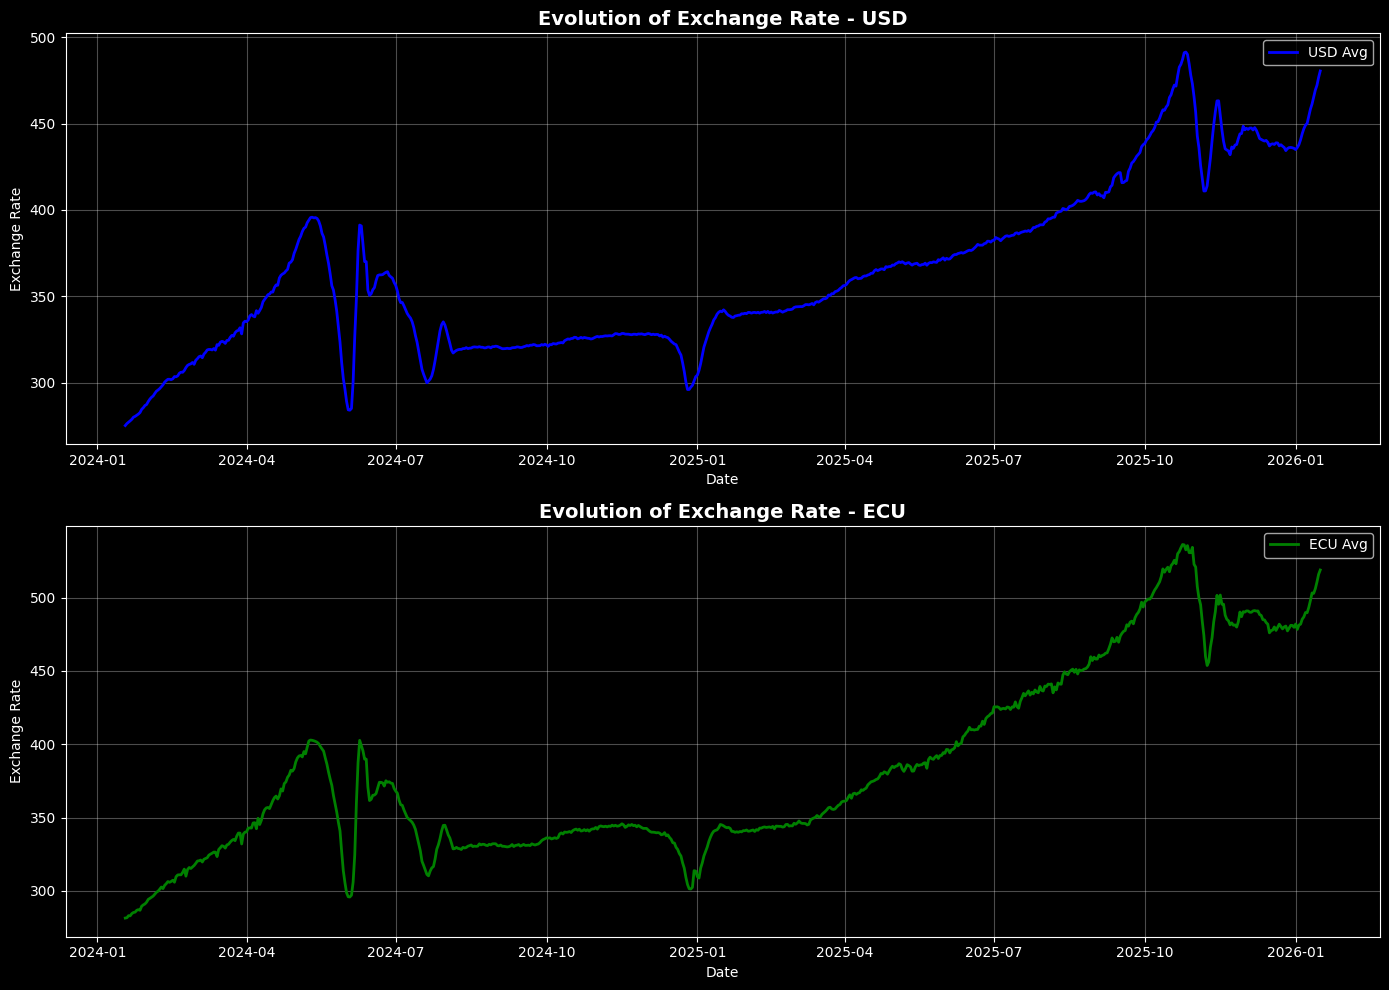

In [36]:
import matplotlib.pyplot as plt

# Create figure with two subplots for USD and ECU
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot USD evolution
axes[0].plot(df_usd.index, df_usd['avg'], label='USD Avg', color='blue', linewidth=2)
axes[0].set_title('Evolution of Exchange Rate - USD', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Exchange Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot ECU evolution
axes[1].plot(df_ecu.index, df_ecu['avg'], label='ECU Avg', color='green', linewidth=2)
axes[1].set_title('Evolution of Exchange Rate - ECU', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Exchange Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Feature ingeneering

In [37]:
# %% [markdown]
# ### Feature Engineering CORREGIDO (sin perder datos)
# %%
# 6. Crear variables objetivo
df_usd['target'] = df_usd['avg'].shift(-1)  # Precio de mañana
df_ecu['target'] = df_ecu['avg'].shift(-1)

# 7. Crear features temporales CORREGIDOS
df_usd['day_of_week'] = df_usd.index.dayofweek
df_usd['month'] = df_usd.index.month
df_usd['day'] = df_usd.index.day
df_usd['year'] = df_usd.index.year

# LAG IMPORTANTE: shift(1) = precio de AYER
df_usd['lag_1'] = df_usd['avg'].shift(1)  # Precio de ayer
df_usd['lag_2'] = df_usd['avg'].shift(2)  # Precio de antier
df_usd['lag_7'] = df_usd['avg'].shift(7)  # Precio hace 7 días

# ROLLING MEAN IMPORTANTE: usar .shift(1) para evitar data leakage
# rolling(7).mean().shift(1) = promedio de últimos 7 días HASTA AYER
df_usd['rolling_mean_7'] = df_usd['avg'].rolling(7).mean().shift(1)
df_usd['rolling_std_7'] = df_usd['avg'].rolling(7).std().shift(1)
df_usd['rolling_min_7'] = df_usd['avg'].rolling(7).min().shift(1)
df_usd['rolling_max_7'] = df_usd['avg'].rolling(7).max().shift(1)

# Features adicionales útiles
df_usd['range'] = df_usd['max'] - df_usd['min']  # Rango del día
df_usd['avg_vs_median'] = df_usd['avg'] - df_usd['median']  # Diferencia con mediana

# Hacer lo mismo para ECU
df_ecu['day_of_week'] = df_ecu.index.dayofweek
df_ecu['month'] = df_ecu.index.month
df_ecu['day'] = df_ecu.index.day
df_ecu['year'] = df_ecu.index.year
df_ecu['lag_1'] = df_ecu['avg'].shift(1)
df_ecu['lag_2'] = df_ecu['avg'].shift(2)
df_ecu['lag_7'] = df_ecu['avg'].shift(7)
df_ecu['rolling_mean_7'] = df_ecu['avg'].rolling(7).mean().shift(1)
df_ecu['rolling_std_7'] = df_ecu['avg'].rolling(7).std().shift(1)
df_ecu['rolling_min_7'] = df_ecu['avg'].rolling(7).min().shift(1)
df_ecu['rolling_max_7'] = df_ecu['avg'].rolling(7).max().shift(1)
df_ecu['range'] = df_ecu['max'] - df_ecu['min']
df_ecu['avg_vs_median'] = df_ecu['avg'] - df_ecu['median']

# 8. ¡NO ELIMINAR TODOS LOS NaNs! Solo los que no podemos usar
# Verificar qué tenemos antes de eliminar
print("="*60)
print("📊 ESTADO ANTES DE ELIMINAR NaNs")
print("="*60)

print(f"\nUSD - Último día ({df_usd.index[-1].date()}):")
print(f"  avg (precio hoy): {df_usd['avg'].iloc[-1]:.2f}")
print(f"  target (precio mañana): {df_usd['target'].iloc[-1]}")  # NaN (correcto)
print(f"  lag_1 (precio ayer): {df_usd['lag_1'].iloc[-1]:.2f}")
print(f"  rolling_mean_7: {df_usd['rolling_mean_7'].iloc[-1]:.2f}")

print(f"\nUSD - Primer día ({df_usd.index[0].date()}):")
print(f"  lag_1: {df_usd['lag_1'].iloc[0]}")  # NaN (no hay día anterior)
print(f"  rolling_mean_7: {df_usd['rolling_mean_7'].iloc[0]}")  # NaN (no hay 7 días anteriores)

# 9. Separar en dos DataFrames diferentes
# DataFrame A: Para ENTRENAMIENTO (días que tienen target)
df_train_usd = df_usd.dropna(subset=['target']).copy()
df_train_ecu = df_ecu.dropna(subset=['target']).copy()

# DataFrame B: Para PREDICCIÓN (último día, aunque no tenga target)
df_hoy_usd = df_usd.iloc[[-1]].copy()  # Solo el último día
df_hoy_ecu = df_ecu.iloc[[-1]].copy()

print("\n" + "="*60)
print("✅ SEPARACIÓN CORRECTA")
print("="*60)

print(f"\n📚 Para ENTRENAMIENTO (días con target):")
print(f"  USD: {len(df_train_usd)} días ({df_train_usd.index[0].date()} - {df_train_usd.index[-1].date()})")
print(f"  ECU: {len(df_train_ecu)} días ({df_train_ecu.index[0].date()} - {df_train_ecu.index[-1].date()})")

print(f"\n🔮 Para PREDICCIÓN (último día = HOY):")
print(f"  USD: {df_hoy_usd.index[0].date()} - Precio: {df_hoy_usd['avg'].iloc[0]:.2f}")
print(f"  ECU: {df_hoy_ecu.index[0].date()} - Precio: {df_hoy_ecu['avg'].iloc[0]:.2f}")

# 10. Ahora SÍ eliminar NaNs solo del DataFrame de entrenamiento
# Pero solo eliminamos filas donde NO TENEMOS SUFICIENTES FEATURES
df_train_usd.dropna(inplace=True)
df_train_ecu.dropna(inplace=True)

print(f"\n🎯 Después de eliminar NaNs del entrenamiento:")
print(f"  USD para entrenar: {len(df_train_usd)} días")
print(f"  ECU para entrenar: {len(df_train_ecu)} días")

# 11. Verificar estructura FINAL
print("\n" + "="*60)
print("📋 ESTRUCTURA FINAL")
print("="*60)

print("\nUSD DataFrame para ENTRENAR shape:", df_train_usd.shape)
print("ECU DataFrame para ENTRENAR shape:", df_train_ecu.shape)

print("\nUSD HOY para PREDECIR shape:", df_hoy_usd.shape)
print("ECU HOY para PREDECIR shape:", df_hoy_ecu.shape)

print("\nPrimeras filas USD para entrenar:")
print(df_train_usd[['avg', 'target', 'day_of_week', 'lag_1', 'rolling_mean_7']].head())

print("\nÚltima fila USD para predecir (HOY):")
print(df_hoy_usd[['avg', 'target', 'day_of_week', 'lag_1', 'rolling_mean_7']])

📊 ESTADO ANTES DE ELIMINAR NaNs

USD - Último día (2026-01-16):
  avg (precio hoy): 480.43
  target (precio mañana): nan
  lag_1 (precio ayer): 476.69
  rolling_mean_7: 465.37

USD - Primer día (2024-01-18):
  lag_1: nan
  rolling_mean_7: nan

✅ SEPARACIÓN CORRECTA

📚 Para ENTRENAMIENTO (días con target):
  USD: 729 días (2024-01-18 - 2026-01-15)
  ECU: 729 días (2024-01-18 - 2026-01-15)

🔮 Para PREDICCIÓN (último día = HOY):
  USD: 2026-01-16 - Precio: 480.43
  ECU: 2026-01-16 - Precio: 518.85

🎯 Después de eliminar NaNs del entrenamiento:
  USD para entrenar: 722 días
  ECU para entrenar: 722 días

📋 ESTRUCTURA FINAL

USD DataFrame para ENTRENAR shape: (722, 27)
ECU DataFrame para ENTRENAR shape: (722, 27)

USD HOY para PREDECIR shape: (1, 27)
ECU HOY para PREDECIR shape: (1, 27)

Primeras filas USD para entrenar:
               avg  target  day_of_week   lag_1  rolling_mean_7
fecha                                                          
2024-01-25  281.11  281.77            3  280

### Entrenamiento del modelo


In [38]:
# Definir features que usaremos (excluyendo 'target')
features = ['avg', 'median', 'min', 'max', 'day_of_week', 'month',
            'lag_1', 'lag_7', 'rolling_mean_7']

print(f"\n🎯 Features seleccionados ({len(features)}):")
for f in features:
    print(f"  • {f}")

# Preparar datos de entrenamiento
X_train_usd = df_train_usd[features]
y_train_usd = df_train_usd['target']

X_train_ecu = df_train_ecu[features]
y_train_ecu = df_train_ecu['target']

# Preparar HOY para predicción
X_hoy_usd = df_hoy_usd[features]
X_hoy_ecu = df_hoy_ecu[features]

print(f"\n📊 Shapes finales:")
print(f"  Entrenamiento USD: X={X_train_usd.shape}, y={y_train_usd.shape}")
print(f"  Predicción HOY USD: X={X_hoy_usd.shape}")
print(f"  Predicción HOY ECU: X={X_hoy_ecu.shape}")

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Usar mejores parámetros encontrados
best_params = {
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.2,
    'subsample': 0.8,
    'colsample_bytree': 1.0,
    'random_state': 42,
    'n_jobs': -1
}

print("\n🚀 Entrenando modelos para PRODUCCIÓN...")
model_usd = xgb.XGBRegressor(**best_params)
model_ecu = xgb.XGBRegressor(**best_params)

model_usd.fit(X_train_usd, y_train_usd)
model_ecu.fit(X_train_ecu, y_train_ecu)

print("✅ Modelos entrenados para producción")


🎯 Features seleccionados (9):
  • avg
  • median
  • min
  • max
  • day_of_week
  • month
  • lag_1
  • lag_7
  • rolling_mean_7

📊 Shapes finales:
  Entrenamiento USD: X=(722, 9), y=(722,)
  Predicción HOY USD: X=(1, 9)
  Predicción HOY ECU: X=(1, 9)

🚀 Entrenando modelos para PRODUCCIÓN...
✅ Modelos entrenados para producción


### PREDICCIÓN REAL PARA MAÑANA


In [39]:
# %%
# Predecir MAÑANA usando datos de HOY
pred_usd_mañana = model_usd.predict(X_hoy_usd)[0]
pred_ecu_mañana = model_ecu.predict(X_hoy_ecu)[0]

print("\n" + "="*60)
print("🎯 PREDICCIÓN REAL PARA MAÑANA")
print("="*60)

fecha_hoy = df_hoy_usd.index[0]
precio_hoy_usd = df_hoy_usd['avg'].iloc[0]
precio_hoy_ecu = df_hoy_ecu['avg'].iloc[0]

print(f"\n📅 Fecha actual (HOY): {fecha_hoy.date()}")
print(f"🔮 Prediciendo para: {(fecha_hoy + pd.Timedelta(days=1)).date()}")

print(f"\n💵 DÓLAR (USD):")
print(f"   • Precio HOY: {precio_hoy_usd:.2f}")
print(f"   • Predicción MAÑANA: {pred_usd_mañana:.2f}")
cambio_usd = ((pred_usd_mañana - precio_hoy_usd) / precio_hoy_usd) * 100
print(f"   • Cambio esperado: {cambio_usd:+.2f}%")

print(f"\n💶 ECU (EURO CUBANO):")
print(f"   • Precio HOY: {precio_hoy_ecu:.2f}")
print(f"   • Predicción MAÑANA: {pred_ecu_mañana:.2f}")
cambio_ecu = ((pred_ecu_mañana - precio_hoy_ecu) / precio_hoy_ecu) * 100
print(f"   • Cambio esperado: {cambio_ecu:+.2f}%")

# Recomendación automática
print(f"\n💡 RECOMENDACIÓN AUTOMÁTICA:")

if cambio_usd > 2.0:
    print("   🚀 USD: SUBIDA FUERTE → OPORTUNIDAD DE COMPRA")
elif cambio_usd > 0.8:
    print("   📈 USD: TENDENCIA ALCISTA → CONSIDERAR COMPRAR")
elif cambio_usd < -2.0:
    print("   ⚠️ USD: BAJA FUERTE → CONSIDERAR VENDER")
elif cambio_usd < -0.8:
    print("   📉 USD: TENDENCIA BAJISTA → PODRÍA VENDER")
else:
    print("   ⚖️ USD: MERCADO ESTABLE → MANTENER POSICIÓN")

print("="*60)

# %% [markdown]
# ### BACKTESTING (solo para evaluación, no para producción)
# %%
# Para evaluar performance histórica (opcional)
print("\n" + "="*60)
print("📊 BACKTESTING (Evaluación histórica - OPCIONAL)")
print("="*60)

# Tomar últimos 30 días para test (simulando pasado)
split_date = df_train_usd.index[-30]

X_bt_train = X_train_usd[X_train_usd.index < split_date]
y_bt_train = y_train_usd[y_train_usd.index < split_date]
X_bt_test = X_train_usd[X_train_usd.index >= split_date]
y_bt_test = y_train_usd[y_train_usd.index >= split_date]

if len(X_bt_train) > 0 and len(X_bt_test) > 0:
    model_bt = xgb.XGBRegressor(**best_params)
    model_bt.fit(X_bt_train, y_bt_train)

    y_pred_bt = model_bt.predict(X_bt_test)

    mae_bt = mean_absolute_error(y_bt_test, y_pred_bt)
    rmse_bt = np.sqrt(mean_squared_error(y_bt_test, y_pred_bt))

    print(f"\n📈 Resultados Backtesting (últimos 30 días):")
    print(f"   MAE: {mae_bt:.4f}")
    print(f"   RMSE: {rmse_bt:.4f}")
    print(f"   Error promedio: {(mae_bt/y_bt_test.mean()*100):.2f}%")
else:
    print("\n⚠️ No hay suficientes datos para backtesting")

print("\n⚠️ NOTA: El backtesting es solo para evaluación histórica.")
print("   Para decisiones reales usa la PREDICCIÓN DE PRODUCCIÓN.")
print("="*60)


🎯 PREDICCIÓN REAL PARA MAÑANA

📅 Fecha actual (HOY): 2026-01-16
🔮 Prediciendo para: 2026-01-17

💵 DÓLAR (USD):
   • Precio HOY: 480.43
   • Predicción MAÑANA: 482.96
   • Cambio esperado: +0.53%

💶 ECU (EURO CUBANO):
   • Precio HOY: 518.85
   • Predicción MAÑANA: 521.07
   • Cambio esperado: +0.43%

💡 RECOMENDACIÓN AUTOMÁTICA:
   ⚖️ USD: MERCADO ESTABLE → MANTENER POSICIÓN

📊 BACKTESTING (Evaluación histórica - OPCIONAL)

📈 Resultados Backtesting (últimos 30 días):
   MAE: 1.7785
   RMSE: 2.1860
   Error promedio: 0.40%

⚠️ NOTA: El backtesting es solo para evaluación histórica.
   Para decisiones reales usa la PREDICCIÓN DE PRODUCCIÓN.
